In [2]:
!git clone https://github.com/Afonso-Leal/unsupervised_water_quality_prediction.git

Cloning into 'unsupervised_water_quality_prediction'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 5), reused 15 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 6.21 KiB | 2.07 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [3]:
!cd unsupervised_water_quality_prediction/
from model_dense import Encoder as enc_dense
from model_dense import Decoder as dec_dense
from model_dense import EncoderDecoder as auto_dense
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from preprossesing import WaterQualityDataOrganization
from trainer import Trainer
from utils import *

ModuleNotFoundError: No module named 'model_dense'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
wq_org = WaterQualityDataOrganization(import_data())
wq_org.preprocessing()

NameError: name 'WaterQualityDataOrganization' is not defined

In [6]:
X_train_dataset = WaterQualityDataset(wq_org.x_train.to_numpy(),wq_org.x_train.to_numpy())
X_val_dataset = WaterQualityDataset(wq_org.x_val.to_numpy(),wq_org.x_val.to_numpy())
X_test_dataset = WaterQualityDataset(wq_org.x_test.to_numpy(),wq_org.x_test.to_numpy())

In [8]:
encoder = enc_dense()
decoder = dec_dense()
model = auto_dense(encoder, decoder)
print(model)

EncoderDecoder(
  (encoder): Encoder(
    (fc0): Sequential(
      (0): Linear(in_features=9, out_features=180, bias=True)
      (1): Linear(in_features=180, out_features=180, bias=True)
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=180, out_features=180, bias=True)
      (4): Dropout(p=0.2, inplace=False)
      (5): Linear(in_features=180, out_features=180, bias=True)
    )
    (fc): Linear(in_features=180, out_features=90, bias=True)
  )
  (decoder): Decoder(
    (fc0): Sequential(
      (0): Linear(in_features=90, out_features=180, bias=True)
      (1): Dropout(p=0.2, inplace=False)
      (2): Linear(in_features=180, out_features=180, bias=True)
      (3): Linear(in_features=180, out_features=180, bias=True)
      (4): Linear(in_features=180, out_features=180, bias=True)
      (5): Dropout(p=0.2, inplace=False)
      (6): Linear(in_features=180, out_features=180, bias=True)
    )
    (fc_2): Linear(in_features=180, out_features=9, bias=True)
  )
)


In [9]:
criterion = nn.MSELoss()  # Change based on your task
optimizer = torch.optim.Adam(model.parameters(), lr= 0.0001)

In [11]:
prob_train = Trainer(
    model = model,
    train_dataset = X_train_dataset,
    val_dataset = X_val_dataset,
    batch_size = 32,
    criterion = criterion,
    optimizer = optimizer
)

cpu


In [12]:
train_losses, val_losse = prob_train.train(num_epochs = 10)


Epoch 1/10


Validating: 100%|██████████| 873/873 [00:03<00:00, 222.70it/s, loss=0.0347]


Train Loss: 0.2997, Val Loss: 0.1504

Epoch 2/10


Validating: 100%|██████████| 873/873 [00:04<00:00, 209.13it/s, loss=0.0414]


Train Loss: 0.1432, Val Loss: 0.1223

Epoch 3/10


...

Train Loss: 0.0947, Val Loss: 0.0488

Epoch 9/10


Validating: 100%|██████████| 873/873 [00:03<00:00, 222.65it/s, loss=0.016]


Train Loss: 0.0969, Val Loss: 0.0662

Epoch 10/10


Validating: 100%|██████████| 873/873 [00:03<00:00, 245.86it/s, loss=0.013]

Train Loss: 0.0978, Val Loss: 0.0695


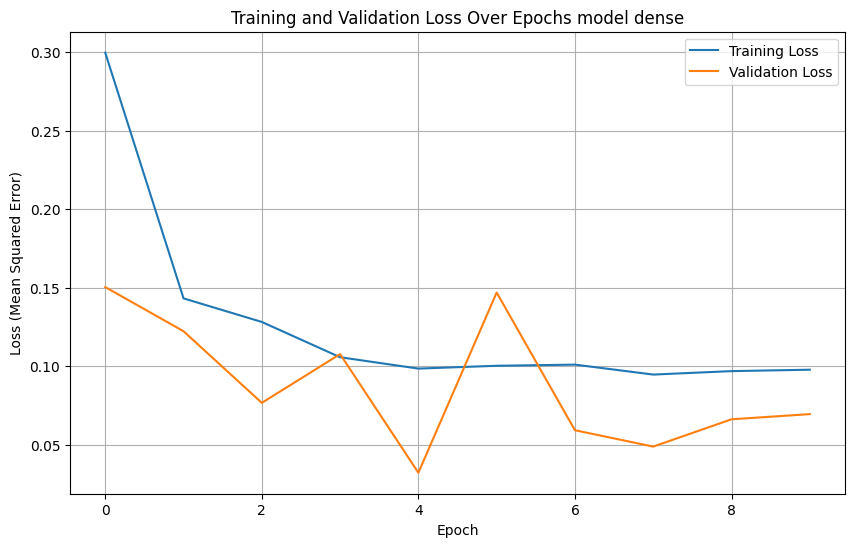

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losse, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs model dense')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from tqdm import tqdm
from torch.utils.data import DataLoader

device = ('cuda' if torch.cuda.is_available() else 'cpu')
test_loader = DataLoader(X_test_dataset, batch_size=32, shuffle=False)

model.to(device)
model.eval()

test_loss = []
outputs = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='Testing')
    for data, target in pbar:
        data, target = data.to(device), target.to(device)

        # Forward pass
        output = model(data.float())
        loss = criterion(output, target)

        # Track loss
        test_loss.append(loss.item())
        outputs.append(output.to(device).numpy())

        pbar.set_postfix({'loss': loss.item()})

Testing: 100%|██████████| 4362/4362 [00:19<00:00, 218.99it/s, loss=0.0105]


In [30]:
import numpy as np
y_pred_flat = np.concatenate(outputs, axis=0)
print(f"Shape of flattened predictions: {y_pred_flat.shape}")

Shape of flattened predictions: (139566, 9)


In [1]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Create a 2x2 grid for 4 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot up to 4 features, or fewer if there aren't that many
num_features_to_plot = min(4, y_pred_flat.shape[1])

for i in range(num_features_to_plot):
  axes[i].plot(wq_org.x_test.to_numpy()[:,i], label="Target")
  axes[i].plot(y_pred_flat[:,i], label="Prediction")
  axes[i].set_title(f'Test data X target data for feature {i}')
  axes[i].legend()
  axes[i].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

NameError: name 'plt' is not defined

In [41]:
__losses_for_test = []
for i in range(y_pred_flat.shape[0]):
  __losses_for_test.append(criterion(torch.from_numpy(y_pred_flat[i]).float(), torch.from_numpy(wq_org.x_test.to_numpy()[i]).float()))

In [46]:
losses_for_test = [float(i) for i in __losses_for_test]

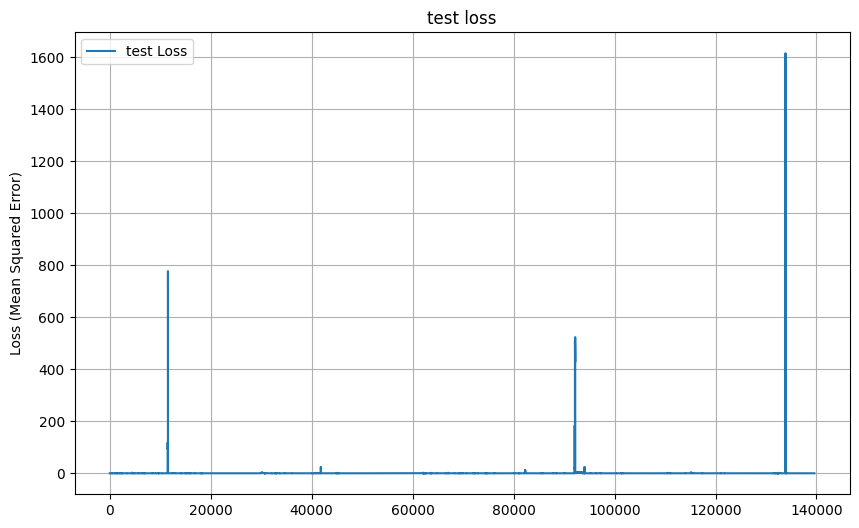

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(losses_for_test, label='test Loss')
plt.title('test loss')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
np.max(losses_for_test)

np.float64(1614.600830078125)

In [50]:
np.min(losses_for_test)

np.float64(0.00016192947805393487)

In [55]:
mean__ = np.mean(losses_for_test)
print(mean__)

0.41099727281164794


In [58]:
sets__ = []
for i in tqdm(losses_for_test):
  if i > mean__:
    sets__.append(1)
  else:
    sets__.append(0)

100%|██████████| 139566/139566 [00:00<00:00, 2694807.40it/s]


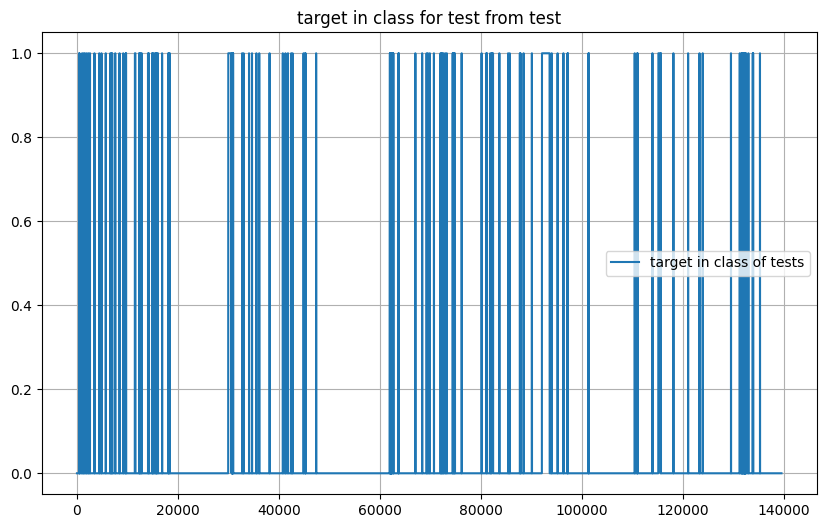

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(sets__, label='target in class of tests')
plt.title('target in class for test from test')
plt.legend()
plt.grid(True)
plt.show()

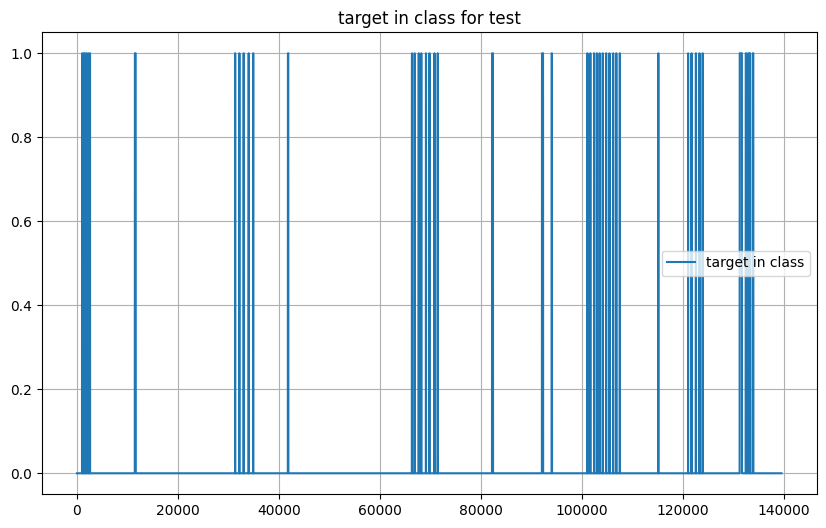

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(wq_org.y_test, label='target in class')
plt.title('target in class for test')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd

conf_matrix = confusion_matrix(sets__, wq_org.y_test)
print("Confusion Matrix:")
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
print(conf_matrix_df)

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0       134054         1396
Actual 1         3183          933


In [65]:
class_report = classification_report(sets__,wq_org.y_test)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    135450
           1       0.40      0.23      0.29      4116

    accuracy                           0.97    139566
   macro avg       0.69      0.61      0.64    139566
weighted avg       0.96      0.97      0.96    139566



In [ ]:
'''
o mais efetivo pra treinar nao seria tirar os casos onde e anomalia?
pra que o treino aprenda a reconstruir so oque nao e anomalia e dai no teste que venha
os valores com anomalia?
'''